In [2]:
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("data.csv") #, parse_dates=['Date', 'start_time', 'end_time'])

df.head(2)

,stage_type,Date,start_time,end_time,duration_(s),average_spo2,spo2_samples
0,1,2024-09-21,01:08:00,01:10:00,120.0,95.0,1
1,1,2024-09-21,01:13:00,01:19:30,390.0,95.0,1


In [4]:
## Check if for each night we have 5 stages 
# <!!!!!!!!!!!!!!!!!!> Nights missing stages 3, 4, and 5 are not considered valuable data.

date_stage = df[['Date', 'stage_type']].drop_duplicates().groupby(by=['Date']).agg(
    check_stage_type=('stage_type', 'count')
).reset_index()

print(date_stage)

         Date  check_stage_type
0  2024-09-20                 4
1  2024-09-21                 2
2  2024-09-28                 1
3  2024-09-29                 5
4  2024-10-01                 4


'2024-09-29'

In [ ]:
# Select a night that has all 5 stages (stage 1 is not valuable, we can ignore it)
best_date_night = date_stage.iloc[date_stage['check_stage_type'].argmax()]['Date']

best_date_night

In [6]:
def plot_stages(df, selected_date):
    df_date = df[df['Date'] == selected_date]
    df_date = df_date.sort_values(["start_time", "end_time"]).reset_index(drop=True)

    id_cycle_to_name = {1:"1:AsleepUnspecified",  2: "2:Awake", 3: "3:Lighter NREM (N1 & N2)", 4: "4:NREM (N3) ", 5: "5:REM"}

    fig, ax = plt.subplots(figsize=(14, 6))

    for index, row in df_date.iterrows():
        ax.plot([row['start_time'], row['end_time']], [row['stage_type'], row['stage_type']], markersize=4, 
                marker='o', linestyle='-', color=f'C{row["stage_type"]}', label=f'{id_cycle_to_name[row["stage_type"]]}')

    ax.set_yticks(list(id_cycle_to_name.keys()))  # Définir les ticks de l'axe Y sur [1, 2, 3, 4, 5]
    ax.set_yticklabels(list(id_cycle_to_name.values()))  # Utiliser les noms des cycles comme labels de l'axe Y

    plt.xticks(rotation=80)

    ax.grid(True)
    ax.set_title(f'Stages during : {selected_date}')

    plt.tight_layout()
    plt.show()

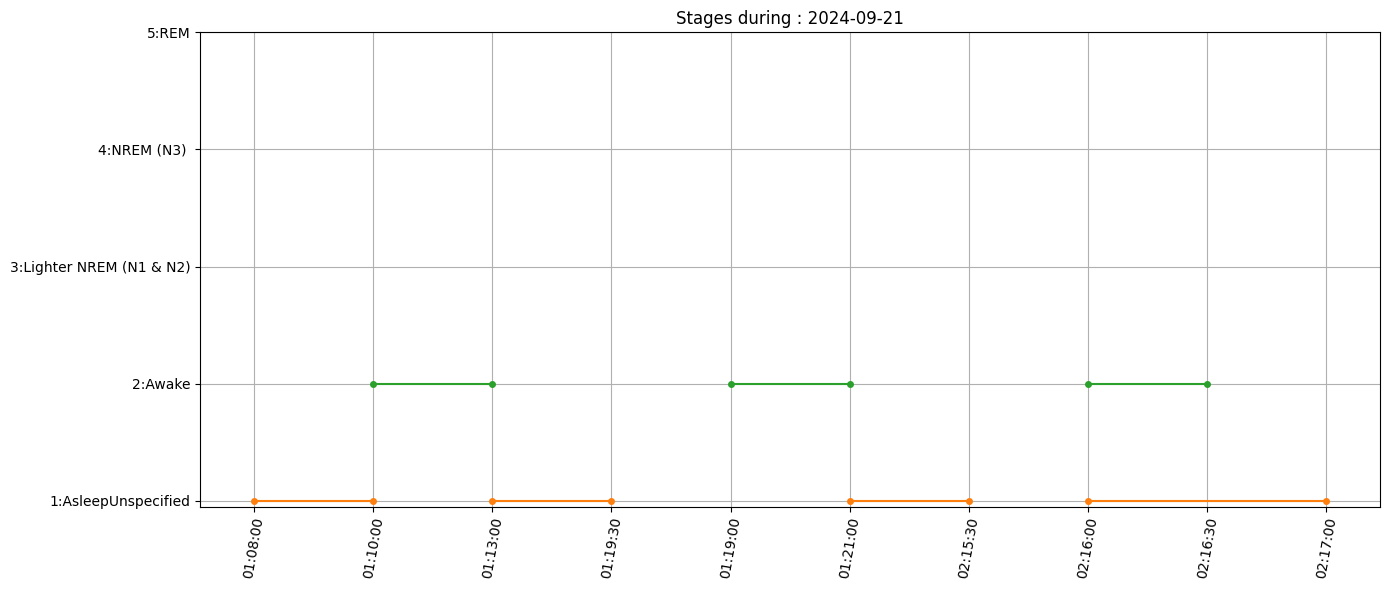

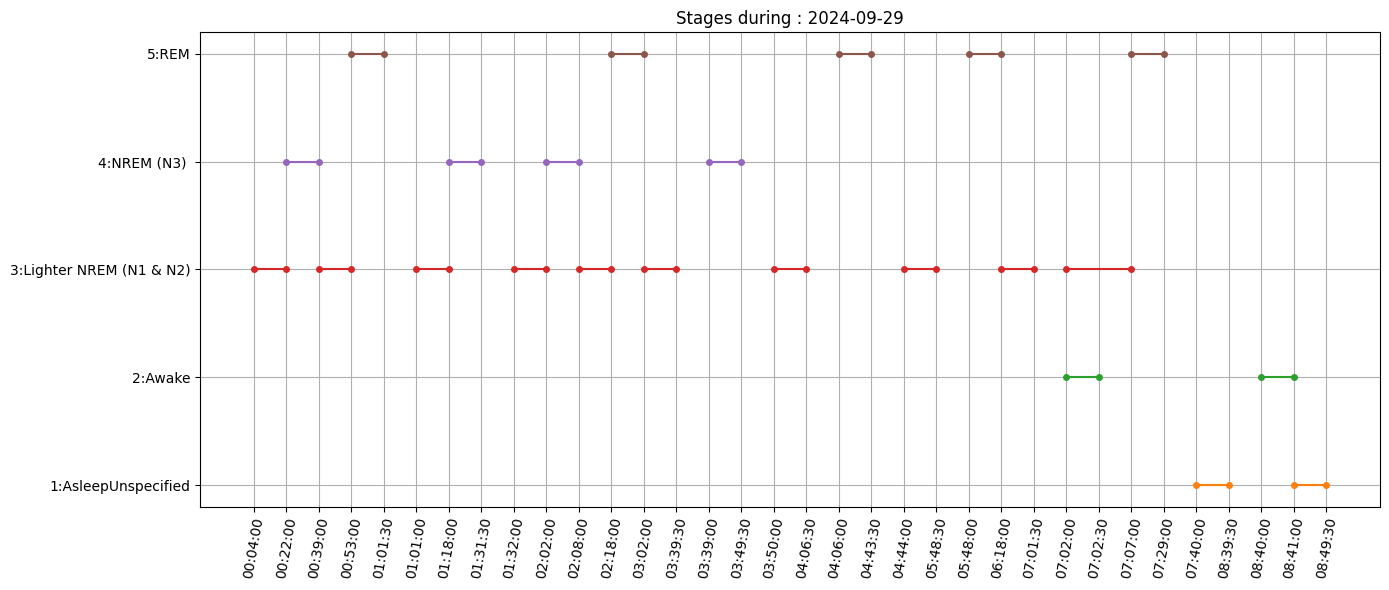

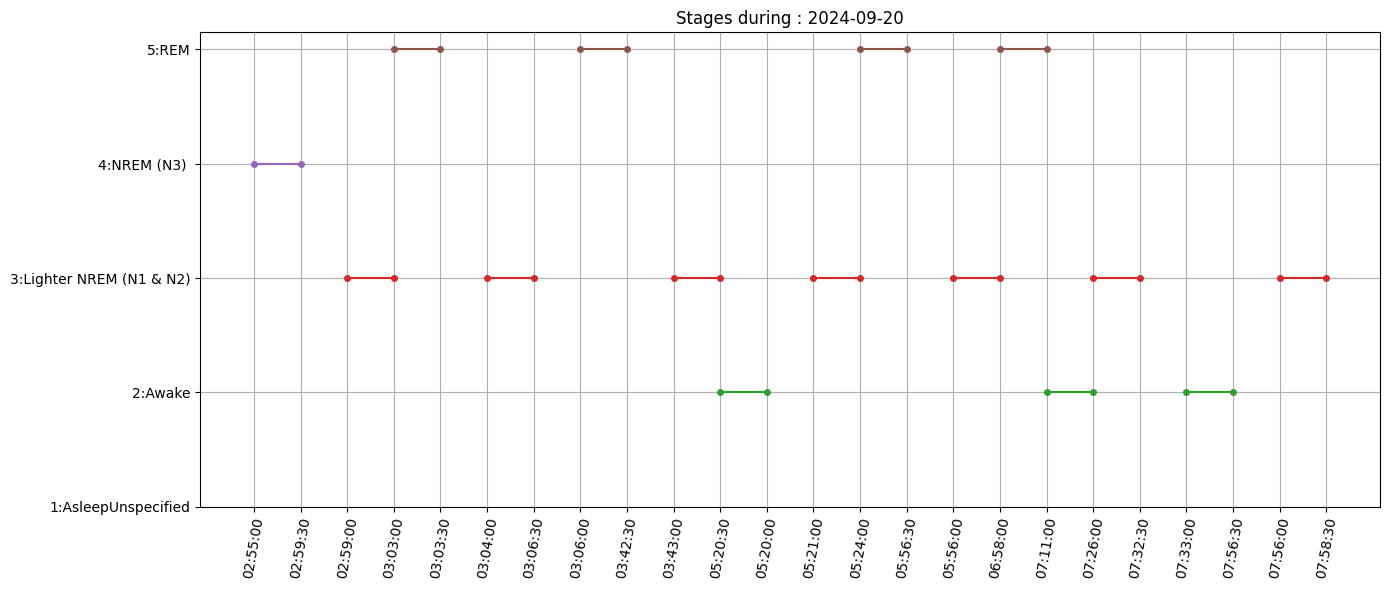

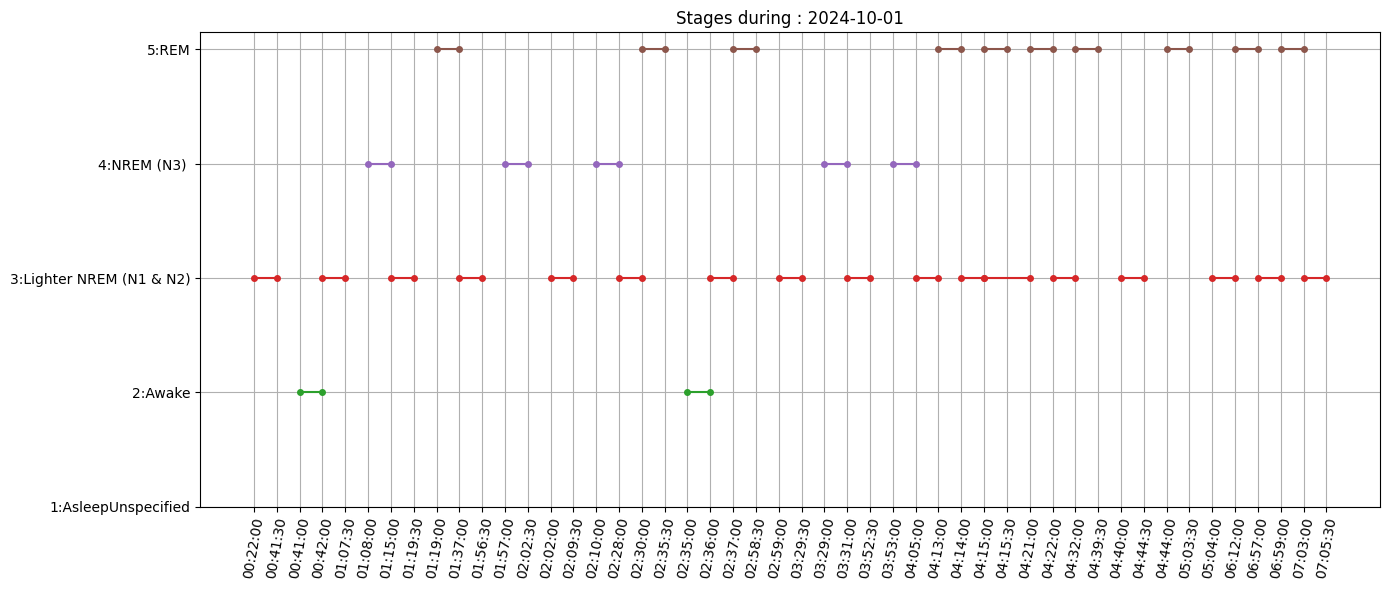

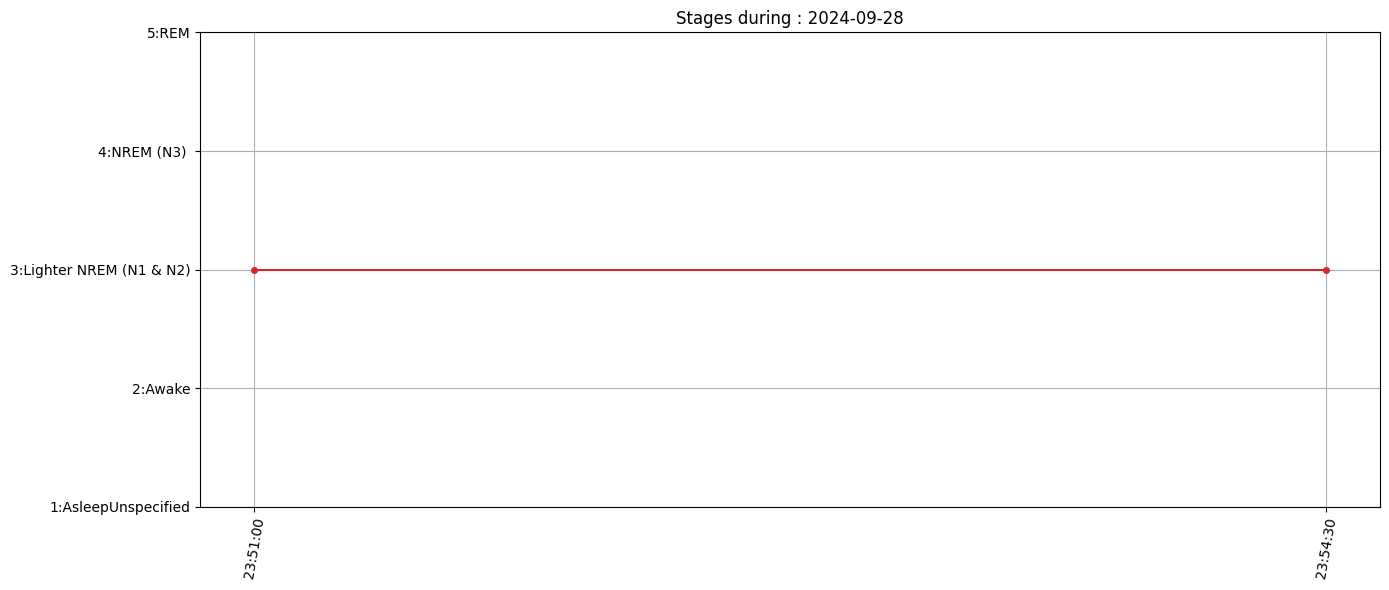

In [7]:
# Plot the duration of cycles per night. 
# <!!!!!!!!!> The diagrams should show stage 2, then 3, then 4, and finally 5, multiple times, which is currently not the case.
for selected_date in df['Date'].drop_duplicates():
    plot_stages(df, selected_date)

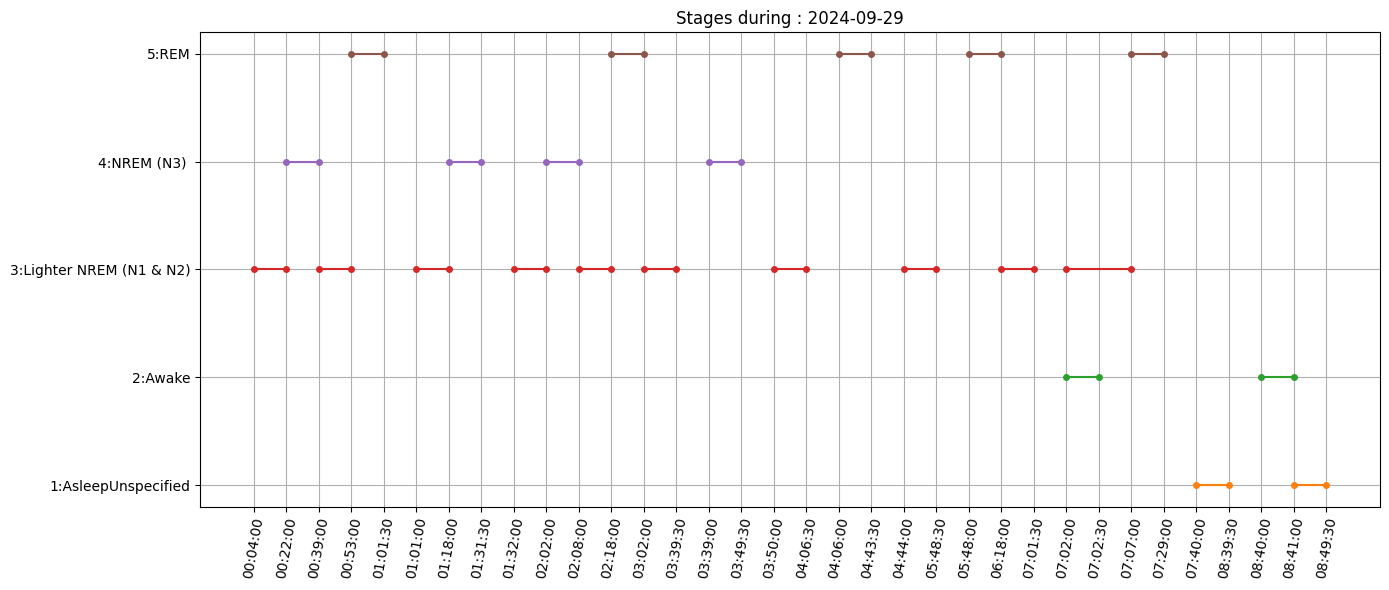

In [111]:
plot_stages(df, best_date_night)

In [11]:
## Add new features 

df = pd.read_csv("data.csv") 

def total_time_of_stage(df, cycle_types, new_column_name):
    filtered_df = df[df['stage_type'].isin(cycle_types)]
    total_time_per_date = filtered_df.groupby('Date')['duration_(s)'].sum().reset_index()
    total_time_per_date.columns = ['Date', new_column_name]
    return df.merge(total_time_per_date, on='Date', how='left')

def stage_percentage(df, stage_column, new_column_name):
    df[new_column_name] = df.apply(
        lambda row: row[stage_column] / row['TST_(s)'] if row['TST_(s)'] > 0 else 0,
        axis=1
    )
    return df

def frequence_stages1(df):
    stage_counts = df[["Date", "stage_type"]].groupby(by=["Date", "stage_type"]).agg(count_stages=('stage_type', 'count')).reset_index()
    df = df.merge(stage_counts, on=['Date', 'stage_type'], how='left')
    return df

def frequence_stages(df, stage_id):
    stage_counts = df[df['stage_type'] == stage_id].groupby(['Date', 'stage_type']).size().reset_index(name=f'count_stage_{stage_id}')    
    df = df.merge(stage_counts.drop(columns=['stage_type']), on=['Date'], how='left', suffixes=('', '_count'))
    df[f'count_stage_{stage_id}'].fillna(0, inplace=True)    
    return df


def compute_max_spo2(df):
    maxspo2 = df.groupby('Date').agg(max_spo2=('average_spo2', 'max')).reset_index()
    df = df.merge(maxspo2, on='Date', how='left')
    return df


df = total_time_of_stage(df, [1, 2], 'TWT_(s)')  # Total Awake Time
df = total_time_of_stage(df, [1, 2, 3, 4, 5], 'TIB_(s)')  # Total Time In Bed
df = total_time_of_stage(df, [3, 4, 5], 'TST_(s)')  # Total Sleep Time
df['SE_%'] = df['TST_(s)'] / df['TIB_(s)'] * 100 # Sleep Efficiency

df = total_time_of_stage(df, [5], 'Total_REM_(s)')
df = total_time_of_stage(df, [4], 'Total_NREM_N3_(s)')
df = total_time_of_stage(df, [3], 'Total_NREM_N1&N2_(s)')
df = total_time_of_stage(df, [2], 'Total_Wake_(s)')

df = stage_percentage(df, 'TWT_(s)', 'TWT_%')
df = stage_percentage(df, 'Total_REM_(s)', 'REM_%')
df = stage_percentage(df, 'Total_NREM_N3_(s)', 'NREM_N3_%')
df = stage_percentage(df, 'Total_NREM_N1&N2_(s)', 'NREM_N1&N2_%')
df = stage_percentage(df, 'Total_Wake_(s)', 'Wake_%')
df = frequence_stages1(df)

df = frequence_stages(df, 1)
df = frequence_stages(df, 2)
df = frequence_stages(df, 3)
df = frequence_stages(df, 4)
df = frequence_stages(df, 5)

df = compute_max_spo2(df)

""""
# TODO, but not valuable data to be able to do it.
-> Sleep Onset Latency (SOL) :
The time it takes to fall asleep after going to bed.
SOL less than 15 minutes is considered normal, whereas a latency greater than 30 minutes can be indicative of insomnia or other sleep disorders.
-> Wake After Sleep Onset (WASO) :
Total time spent awake after initially falling asleep.
A WASO less than 30 minutes is considered normal. Higher values indicate fragmented sleep and reduced sleep quality.
-> Number of cycles
"""

# TODO: add more conditions, but since we do not have enough data, wasn't able to complete them.
df['target'] = np.where(
    (df['max_spo2'] > 93) &  
    (df['REM_%'].between(20, 35)) &   # (df['REM_%'].between(20, 25)) &  
    (df['TWT_%'] < 5) &  
    (df['SE_%'] >= 80) &  
    (df['TST_(s)'] >= 6 * 60 * 60) &  
    (df['count_stage_5'] != 4), 
    1, # Good sleep
    0  # Bad sleep
)

df.to_csv("enhaced_data.csv", index=False)

# Display
df[df["Date"] == '2024-09-21'].sort_values(["Date", "start_time"	,"end_time"])

,stage_type,Date,start_time,end_time,duration_(s),average_spo2,spo2_samples,TWT_(s),TIB_(s),TST_(s),...,NREM_N1&N2_%,Wake_%,count_stages,count_stage_1,count_stage_2,count_stage_3,count_stage_4,count_stage_5,max_spo2,target
0,1,2024-09-21,01:08:00,01:10:00,120.0,95.0,1,4170.0,4170.0,NaN,...,0.0,0.0,4,4.0,3.0,0.0,0.0,0.0,95.0,0
9,2,2024-09-21,01:10:00,01:13:00,180.0,95.0,1,4170.0,4170.0,NaN,...,0.0,0.0,3,4.0,3.0,0.0,0.0,0.0,95.0,0
1,1,2024-09-21,01:13:00,01:19:30,390.0,95.0,1,4170.0,4170.0,NaN,...,0.0,0.0,4,4.0,3.0,0.0,0.0,0.0,95.0,0
10,2,2024-09-21,01:19:00,01:21:00,120.0,95.0,1,4170.0,4170.0,NaN,...,0.0,0.0,3,4.0,3.0,0.0,0.0,0.0,95.0,0
2,1,2024-09-21,01:21:00,02:15:30,3270.0,95.0,1,4170.0,4170.0,NaN,...,0.0,0.0,4,4.0,3.0,0.0,0.0,0.0,95.0,0
11,2,2024-09-21,02:16:00,02:16:30,30.0,95.0,1,4170.0,4170.0,NaN,...,0.0,0.0,3,4.0,3.0,0.0,0.0,0.0,95.0,0
3,1,2024-09-21,02:16:00,02:17:00,60.0,95.0,1,4170.0,4170.0,NaN,...,0.0,0.0,4,4.0,3.0,0.0,0.0,0.0,95.0,0


In [12]:
# Take valuable data
columns_to_removed = ['start_time', 'end_time', 'duration_(s)', 'spo2_samples', 'count_stages', 'stage_type', 'average_spo2']
columns_to_display = df.columns.difference(columns_to_removed)
df[columns_to_display].drop_duplicates() #[df["Date"] == "2024-09-29"]

,Date,NREM_N1&N2_%,NREM_N3_%,REM_%,SE_%,TIB_(s),TST_(s),TWT_%,TWT_(s),Total_NREM_N1&N2_(s),...,Total_REM_(s),Total_Wake_(s),Wake_%,count_stage_1,count_stage_2,count_stage_3,count_stage_4,count_stage_5,max_spo2,target
0,2024-09-21,0.000000,0.000000,0.000000,NaN,4170.0,NaN,0.000000,4170.0,NaN,...,NaN,330.0,0.000000,4.0,3.0,0.0,0.0,0.0,95.0,0
4,2024-09-29,0.575281,0.105618,0.319101,86.491740,30870.0,26700.0,0.156180,4170.0,15360.0,...,8520.0,90.0,0.003371,2.0,2.0,10.0,4.0,5.0,96.0,0
6,2024-09-20,0.671698,0.016981,0.311321,87.171053,18240.0,15900.0,0.147170,2340.0,10680.0,...,4950.0,2340.0,0.147170,0.0,3.0,7.0,1.0,4.0,95.0,0
14,2024-10-01,0.581569,0.110834,0.307597,99.504337,24210.0,24090.0,0.004981,120.0,14010.0,...,7410.0,120.0,0.004981,0.0,2.0,17.0,5.0,10.0,97.5,0
23,2024-09-28,1.000000,NaN,NaN,100.000000,210.0,210.0,NaN,NaN,210.0,...,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,95.0,0


In [117]:
# Normalization of the data

min_max_columns = ['TIB_(s)', 'TST_(s)', 'Total_NREM_N1&N2_(s)', 'Total_REM_(s)', 'Total_Wake_(s)',
                   'count_stage_1', 'count_stage_2', 'count_stage_3', 'count_stage_4', 'count_stage_5']
standard_columns = ['NREM_N1&N2_%', 'NREM_N3_%', 'REM_%', 'SE_%', 'TWT_%', 'Wake_%']
robust_columns = ['max_spo2']

#TODO: review
df[min_max_columns] = df[min_max_columns].fillna(df[min_max_columns].median())
df[standard_columns] = df[standard_columns].fillna(df[standard_columns].median())
df[robust_columns] = df[robust_columns].fillna(df[robust_columns].median())

min_max_scaler = MinMaxScaler()
df[min_max_columns] = min_max_scaler.fit_transform(df[min_max_columns])

standard_scaler = StandardScaler()
df[standard_columns] = standard_scaler.fit_transform(df[standard_columns])

robust_scaler = RobustScaler()
df[robust_columns] = robust_scaler.fit_transform(df[robust_columns])

columns_to_display = df.columns.difference(['start_time', 'end_time', 'duration_(s)', 'spo2_samples', 'count_stages', 'stage_type', 'average_spo2'])
data = df[columns_to_display].drop_duplicates().dropna() #[df["Date"] == "2024-09-29"]

data

,Date,NREM_N1&N2_%,NREM_N3_%,REM_%,SE_%,TIB_(s),TST_(s),TWT_%,TWT_(s),Total_NREM_N1&N2_(s),...,Total_REM_(s),Total_Wake_(s),Wake_%,count_stage_1,count_stage_2,count_stage_3,count_stage_4,count_stage_5,max_spo2,target
4,2024-09-29,0.134909,0.542189,0.389788,-0.933855,1.000000,1.000000,1.098183,4170.0,1.000000,...,1.000000,0.000000,-0.489249,0.5,0.666667,0.588235,0.8,0.5,0.0,0
6,2024-09-20,0.670699,-1.490374,0.301662,-0.826077,0.588063,0.592299,0.976784,2340.0,0.691089,...,0.000000,1.000000,2.081027,0.0,1.000000,0.411765,0.2,0.4,-0.4,0
14,2024-10-01,0.169853,0.661808,0.259479,1.130678,0.782779,0.901472,-0.939051,120.0,0.910891,...,0.689076,0.013333,-0.460462,0.0,0.666667,1.000000,1.0,1.0,0.6,0


In [97]:
# ML Model
X = data.drop(columns=['target', 'Date'])
y = data['target'] 

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, y_train = X, y

rf_model = RandomForestClassifier(
    n_estimators=100,    
    max_depth=5,        
    random_state=42,      
    class_weight='balanced' 
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_train)

accuracy = accuracy_score(y_train, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y_train, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_train, y_pred))

Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix:
[[3]]
